In [14]:
from transformers import SamModel, SamProcessor
import torch 

model = SamModel.from_pretrained("facebook/sam-vit-base")
processor = SamProcessor.from_pretrained("facebook/sam-vit-base")

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print("SAM loaded!")

/DATA/home/jgarcia/miniconda3/envs/sam_env_c5/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 314/314 [00:00<00:00, 28931.95it/s]
The image processor of type `SamImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


SAM loaded!


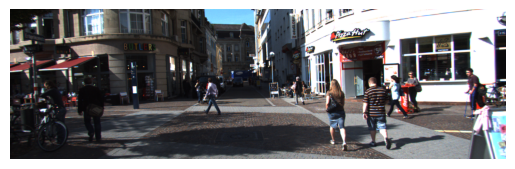

In [13]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("/DATA/home/jgarcia/SpectralSegmentation/C5-Project/Week2/data/kitti-mots/train/img/0019_000576.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

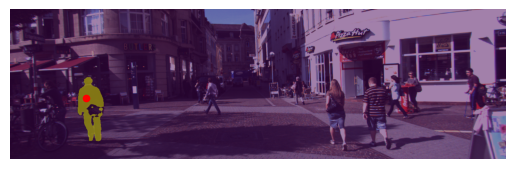

In [25]:
input_points = [[[190, 220]]]  
input_labels = [[1]]          

inputs = processor(
    image,
    input_points=input_points,
    input_labels=input_labels,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

masks = processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)

mask = masks[0][0][0].numpy()

import matplotlib.pyplot as plt


plt.imshow(image)

x, y = input_points[0][0]
plt.scatter(x, y, c="red", s=20, marker="o")

plt.imshow(mask, alpha=0.5)
plt.axis("off")
plt.show()

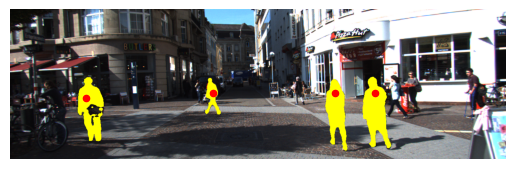

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

points = [[505,210], [810,210], [910,210], [190,220]]

result = image.copy()

colors = [
    [255,0,0],   # red
    [0,255,0],   # green
    [0,0,255],   # blue
    [255,255,0]  # yellow
]

for i, point in enumerate(points):

    inputs = processor(
        image,
        input_points=[[[point[0], point[1]]]],
        input_labels=[[1]],
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    masks = processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs["original_sizes"].cpu(),
        inputs["reshaped_input_sizes"].cpu()
    )

    mask = masks[0][0][0].numpy().astype(bool)

    # draw mask only where mask == True
    result[mask] = [255,255,0] 

plt.imshow(result)

for point in points:
    plt.scatter(point[0], point[1], c="RED", s=20)

plt.axis("off")
plt.show()

In [7]:
import sys
sys.path.append("/DATA/home/jgarcia/SpectralSegmentation/C5-Project/Week2/src")
from utils.kitti_dataset_motsio import KittiDataset

dataset = KittiDataset(
    "/DATA/home/jgarcia/SpectralSegmentation/C5-Project/Week2/data/KITTI-MOTS/training",
    "/DATA/home/jgarcia/SpectralSegmentation/C5-Project/Week2/data/KITTI-MOTS/instances_txt",
    "/DATA/home/jgarcia/SpectralSegmentation/C5-Project/Week2/src/utils/val.seqmap"
)

print(f"Dataset size: {len(dataset)} samples")

image, target = dataset[0]

print("Image shape:", image.shape)
print("Masks shape:", target["masks"].shape)
print("Labels:", target["labels"])

Loading seqmap...
Dataset size: 2981 samples
Image shape: torch.Size([3, 375, 1242])
Masks shape: torch.Size([3, 375, 1242])
Labels: tensor([1, 1, 1])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Class IDs in the sample: [1 1 1 1 1 1 1 1 2]


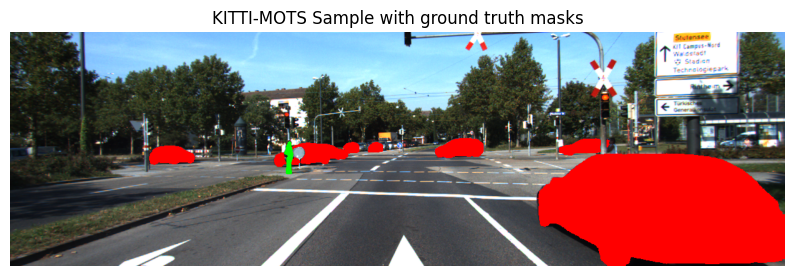

In [12]:
import numpy as np
import matplotlib.pyplot as plt

image, target = dataset[102]

image = image.permute(1,2,0).numpy()
masks = target["masks"].numpy()
class_ids = target["labels"].numpy()

result = image.copy()

colors = {
    1: [255,0,0],   # car → red
    2: [0,255,0],   # pedestrian → green
}

for mask, cls in zip(masks, class_ids):

    mask = mask.astype(bool)

    color = colors.get(cls, [255,255,255])

    result[mask] = color

print(f"Class IDs in the sample: {class_ids}")

plt.figure(figsize=(10,5))
plt.title("KITTI-MOTS Sample with ground truth masks")
plt.imshow(result)
plt.axis("off")
plt.show()

In [39]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import cv2


def compute_iou(pred, gt):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    intersection = (pred & gt).sum()
    union = (pred | gt).sum()

    if union == 0:
        return 0

    return intersection / union

def random_point_from_mask(mask):

    ys, xs = np.where(mask)

    idx = np.random.randint(len(xs))

    return [xs[idx], ys[idx]]

def interior_point_from_mask(mask):

    mask = mask.astype(np.uint8)

    # distance to nearest background pixel
    dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)

    # location of maximum distance (most interior pixel)
    y, x = np.unravel_index(dist.argmax(), dist.shape)

    return [x, y]

def random_edge_point_from_mask(mask):

    mask = mask.astype(np.uint8)

    # erode mask to remove boundary
    kernel = np.ones((3,3), np.uint8)
    eroded = cv2.erode(mask, kernel)

    # boundary = original mask - eroded mask
    edges = mask - eroded

    ys, xs = np.where(edges)

    idx = np.random.randint(len(xs))

    return [xs[idx], ys[idx]]

ious = []
car_ious = []
pedestrian_ious = []

best_iou = -1
worst_iou = 2

best_sample = None
worst_sample = None

for i in tqdm(range(len(dataset))):

    image, target = dataset[i]

    image_np = (image.permute(1,2,0).numpy()*255).astype(np.uint8)
    masks = target["masks"].numpy()
    labels = target["labels"].numpy()

    if len(masks) == 0:
        continue

    for gt_mask, label in zip(masks, labels):

        point = random_edge_point_from_mask(gt_mask)

        inputs = processor(
            image_np,
            input_points=[[[point[0], point[1]]]],
            input_labels=[[1]],
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        pred_masks = processor.image_processor.post_process_masks(
            outputs.pred_masks.cpu(),
            inputs["original_sizes"].cpu(),
            inputs["reshaped_input_sizes"].cpu()
        )

        pred_mask = pred_masks[0][0][0].numpy()

        if pred_mask.shape != gt_mask.shape:
            pred_mask = cv2.resize(
                pred_mask.astype(np.uint8),
                (gt_mask.shape[1], gt_mask.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )

        iou = compute_iou(pred_mask, gt_mask)

        ious.append(iou)

        if label == 1:
            car_ious.append(iou)
        elif label == 2:
            pedestrian_ious.append(iou)

        # store best example
        if iou > best_iou:
            best_iou = iou
            best_sample = (image_np.copy(), gt_mask.copy(), pred_mask.copy(), point)

        # store worst example
        if iou < worst_iou:
            worst_iou = iou
            worst_sample = (image_np.copy(), gt_mask.copy(), pred_mask.copy(), point)

100%|██████████| 2981/2981 [18:50<00:00,  2.64it/s] 


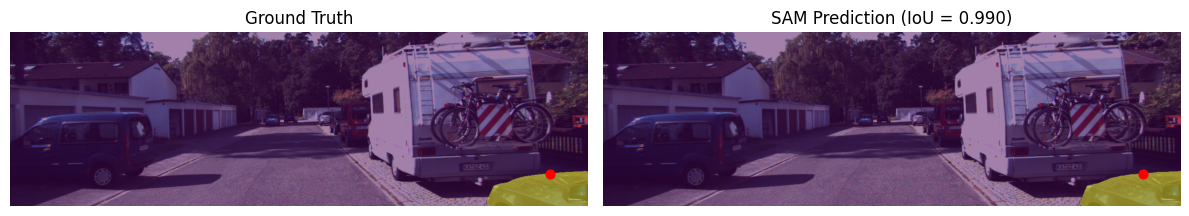

In [40]:
img, gt, pred, point = best_sample

plt.figure(figsize=(12,5))

# Ground truth
plt.subplot(1,2,1)
plt.title(f"Ground Truth")
plt.imshow(img)
plt.imshow(gt, alpha=0.5)
plt.scatter(point[0], point[1], c="red", s=40)
plt.axis("off")

# Prediction
plt.subplot(1,2,2)
plt.title(f"SAM Prediction (IoU = {best_iou:.3f})")
plt.imshow(img)
plt.imshow(pred, alpha=0.5)
plt.scatter(point[0], point[1], c="red", s=40)
plt.axis("off")

plt.tight_layout()
plt.show()

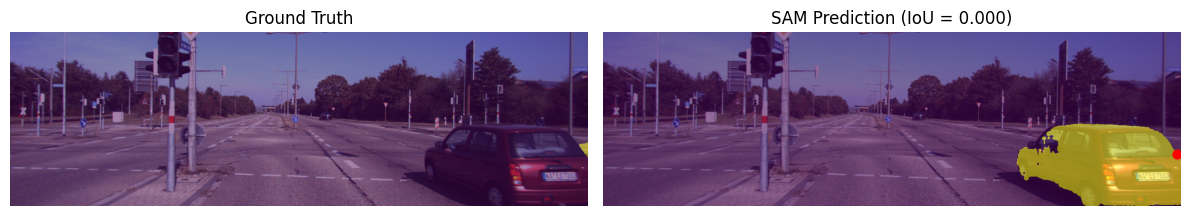

In [41]:
img, gt, pred, point = worst_sample

plt.figure(figsize=(12,5))

# Ground truth
plt.subplot(1,2,1)
plt.title(f"Ground Truth")
plt.imshow(img)
plt.imshow(gt, alpha=0.5)
plt.axis("off")

# Prediction
plt.subplot(1,2,2)
plt.title(f"SAM Prediction (IoU = {worst_iou:.3f})")
plt.imshow(img)
plt.imshow(pred, alpha=0.59)
plt.scatter(point[0], point[1], c="red", s=40)
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print(f"Mean IoU for cars: {np.mean(car_ious):.4f} over {len(car_ious)} samples")
print(f"Mean IoU for pedestrians: {np.mean(pedestrian_ious):.4f} over {len(pedestrian_ious)} samples")
print(f"Mean IoU: {np.mean(ious):.4f}")
print(f"Num objects evaluated: {len(ious)}")





Mean IoU for cars: 0.6631 over 8029 samples
Mean IoU for pedestrians: 0.6223 over 3347 samples
Mean IoU: 0.6511
Num objects evaluated: 11376


In [37]:
import numpy as np

min_iou = np.min(ious)
max_iou = np.max(ious)

print("Lowest IoU:", min_iou)
print("Highest IoU:", max_iou)

Lowest IoU: 0.0
Highest IoU: 0.988817106804186


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# take one mask from the dataset
image, target = dataset[0]

mask = target["masks"][0].numpy()

# convert image tensor to numpy image
image = (image.permute(1,2,0).numpy() * 255).astype(np.uint8)

# get points from the three strategies
p_random = random_point_from_mask(mask)
p_edge = random_edge_point_from_mask(mask)
p_interior = interior_point_from_mask(mask)

plt.figure(figsize=(6,6))

plt.imshow(image)
plt.imshow(mask, alpha=0.5)

# plot points
plt.scatter(p_edge[0], p_edge[1], c="red", s=20, label="Edge point")
plt.scatter(p_random[0], p_random[1], c="blue", s=20, label="Random point")
plt.scatter(p_interior[0], p_interior[1], c="green", s=20, label="Interior point")

plt.legend()
plt.title("Prompt Point Selection Strategies")
plt.axis("off")

plt.show()

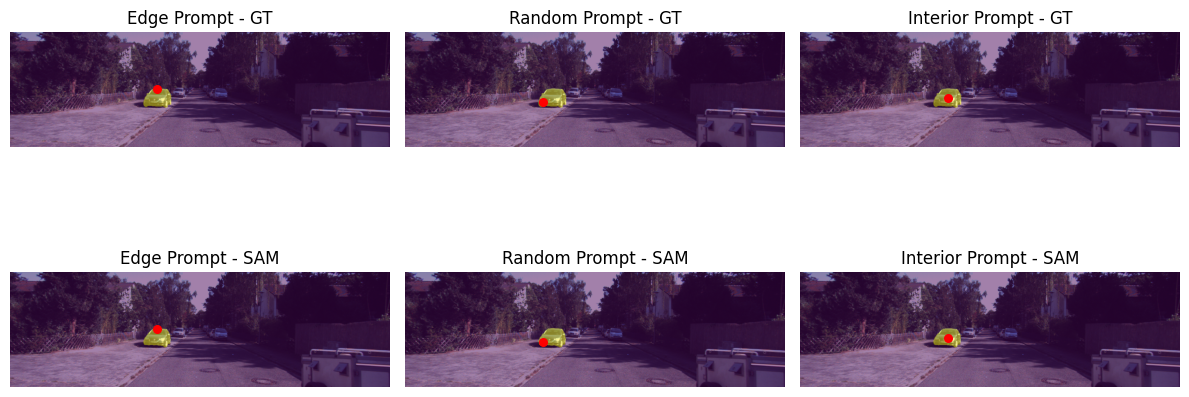

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# take one sample
image, target = dataset[880]

mask = target["masks"][0].numpy()

# convert image tensor to numpy image
image_np = (image.permute(1,2,0).numpy() * 255).astype(np.uint8)

# prompt points
p_edge = random_edge_point_from_mask(mask)
p_random = random_point_from_mask(mask)
p_interior = interior_point_from_mask(mask)

points = [p_edge, p_random, p_interior]
titles = ["Edge Prompt", "Random Prompt", "Interior Prompt"]

predictions = []

for point in points:

    inputs = processor(
        image_np,
        input_points=[[[point[0], point[1]]]],
        input_labels=[[1]],
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    pred_masks = processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs["original_sizes"].cpu(),
        inputs["reshaped_input_sizes"].cpu()
    )

    pred_mask = pred_masks[0][0][0].numpy()

    if pred_mask.shape != mask.shape:
        pred_mask = cv2.resize(
            pred_mask.astype(np.uint8),
            (mask.shape[1], mask.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

    predictions.append(pred_mask)


# plotting
fig, axes = plt.subplots(2,3, figsize=(12,6))

for i in range(3):

    # GT row
    axes[0,i].imshow(image_np)
    axes[0,i].imshow(mask, alpha=0.5)
    axes[0,i].scatter(points[i][0], points[i][1], c="red", s=30)
    axes[0,i].set_title(f"{titles[i]} - GT")
    axes[0,i].axis("off")

    # prediction row
    axes[1,i].imshow(image_np)
    axes[1,i].imshow(predictions[i], alpha=0.5)
    axes[1,i].scatter(points[i][0], points[i][1], c="red", s=30)
    axes[1,i].set_title(f"{titles[i]} - SAM")
    axes[1,i].axis("off")

plt.tight_layout()
plt.show()